In [1]:
#Import packages used
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import scipy.optimize

import sys
sys.path.append('C:\\Users\\bi1ojm\\Documents\\GitHub\\FeedOrFold\\EOsimSuite\\')
from EOsimsuite import EOsimsuite as EOsim

In [2]:
#Sensitivity function - rs are resource concs, specInd is the index of the species under consideration, C is the consumption matrix, delW is the resource values and D is the mortality rate
def sensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    sens = Vmax*monodA*monodG

    return sens

#Gradient of the sensitivity function in the resource space
def gradSensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    sensGrad = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    dMonodG = Kms[-1,-1]/(rs[-1] + Kms[specInd,-1])**2
    
    monodA = rs[specInd]/(rs[specInd] + Kms[specInd,specInd])
    dMonodA = Kms[specInd,specInd]/(rs[specInd] + Kms[specInd,specInd])**2
    
    sensGrad[-1] = dMonodG*monodA*Vmax
    sensGrad[specInd] = dMonodA*monodG*Vmax
    
    return sensGrad

#Impact function for a single species
def impactFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    Ys = EOparams['Ys']
    Cs = EOparams['Cs']
    
    impact = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    for i in range(len(rs)):
        if i == specInd: #If this is the missing amino acid
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA #Amount of amino acid being used by the strain at this time and converted to biomass
        elif i == len(rs)-1: #If this is the glucose
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA - sum(Cs[specInd,:-1])*Vmax*monodG #first term is amount of glucose being converted to biomas, second is amount being converted to amino acids
        else: #If this is any of the (potentially) secreted amino acids
            impact[i] = Cs[specInd,i]*Vmax*monodG

    return impact

def instInteract(rs,alphInd,betInd,EOparams):
    return(np.dot(impactFunc(rs,betInd,EOparams),gradSensFunc(rs,alphInd,EOparams)))

def intrinsicGR(rs,alphInd,EOparams,sysParams):
    return(np.dot(gradSensFunc(rs,alphInd,EOparams),sysParams['D']*(sysParams['rIn']-rs)))

In [3]:
#2-species function test
Kms = np.array([[0.8,-1,1.8],[-1,1.4,0.7]]) #Proline auxotroph then tryptophan auxotroph
Ys = np.array([[5,0,1],[0,10,1]])
Cs = np.array([[0,0.025,-1],[0.05,0,-1]]) #Rate at which glucose is converted into relevant amino acids
Vmax = 0.4

EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}

DilRate = 0.01

proConc = 0.
tryConc = 0.
        
rIn = np.array([proConc,tryConc,2])
sysParams = {'rIn':rIn}

In [4]:
#Generate interaction array and allogenic acceleration array for proline auxotroph
minG = 0
maxG = 3
minP = 0
maxP = 0.3

sampPtsG = 100
sampPtsP = 100

gList = np.linspace(minG,maxG,sampPtsG)
pList = np.linspace(minP,maxP,sampPtsP)

gField, pField = np.meshgrid(gList, pList)

gStep = gField[1,0] - gField[0,0]
pStep = pField[0,1] - pField[0,0]

impactsPonP = np.zeros((sampPtsG,sampPtsP,3))
impactsWonP = np.zeros((sampPtsG,sampPtsP,3))
sensGradsP = np.zeros((sampPtsG,sampPtsP,3))
PonP = np.zeros((sampPtsG,sampPtsP))
WonP = np.zeros((sampPtsG,sampPtsP))
sigP = np.zeros((sampPtsG,sampPtsP,3))
AAp = np.zeros((sampPtsG,sampPtsP))

for gInd in range(sampPtsG):
    for pInd in range(sampPtsP):
        r = np.array([pField[gInd,pInd],1,gField[gInd,pInd]])
        
        impactsPonP[gInd,pInd,:] = impactFunc(r,0,EOparams)
        impactsWonP[gInd,pInd,:] = impactFunc(r,1,EOparams)
        sensGradsP[gInd,pInd,:] = gradSensFunc(r,0,EOparams)
        
        PonP[gInd,pInd] = np.dot(impactsPonP[gInd,pInd,:],sensGradsP[gInd,pInd,:])
        WonP[gInd,pInd] = np.dot(impactsWonP[gInd,pInd,:],sensGradsP[gInd,pInd,:])
        
        sigP[gInd,pInd,:] = DilRate*(rIn-r)
        AAp[gInd,pInd] = np.dot(sigP[gInd,pInd,:],sensGradsP[gInd,pInd,:])

In [5]:
#Repeat for tryptophan auxotroph
minW = 0
maxW = 0.3

sampPtsW = 100

gList = np.linspace(minG,maxG,sampPtsG)
wList = np.linspace(minW,maxW,sampPtsW)

gField, wField = np.meshgrid(gList, wList)
wStep = wField[0,1] - wField[0,0]


impactsPonW = np.zeros((sampPtsG,sampPtsW,3))
impactsWonW = np.zeros((sampPtsG,sampPtsW,3))
sensGradsW = np.zeros((sampPtsG,sampPtsW,3))
PonW = np.zeros((sampPtsG,sampPtsW))
WonW = np.zeros((sampPtsG,sampPtsW))
AAw = np.zeros((sampPtsG,sampPtsW))
sigW = np.zeros((sampPtsG,sampPtsW,3))

for gInd in range(sampPtsG):
    for wInd in range(sampPtsW):
        r = np.array([1,wField[gInd,wInd],gField[gInd,wInd]])
        
        impactsPonW[gInd,wInd,:] = impactFunc(r,0,EOparams)
        impactsWonW[gInd,wInd,:] = impactFunc(r,1,EOparams)
        sensGradsW[gInd,wInd,:] = gradSensFunc(r,1,EOparams)
        
        PonW[gInd,wInd] = np.dot(impactsPonW[gInd,wInd,:],sensGradsW[gInd,wInd,:])
        WonW[gInd,wInd] = np.dot(impactsWonW[gInd,wInd,:],sensGradsW[gInd,wInd,:])
        
        sigW[gInd,wInd,:] = DilRate*(rIn-r)
        AAw[gInd,wInd] = np.dot(sigW[gInd,wInd,:],sensGradsW[gInd,wInd,:])

In [6]:
#Generate a chemostat model to get equilibrium r*
B0 = np.array([0.5,0.1])

chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
chemSim.set_timeSettings(tSpan = [0,10000], dt=0.1)
chemSim.set_dilSettings(D=DilRate,transT=0.1)
chemSim.set_instInteract(instInteract)
chemSim.set_intrinsicGR(intrinsicGR)
chemSim.simEOmodel('Chemostat')

chemSim.rStar = chemSim.resTimeseries[:,-1]

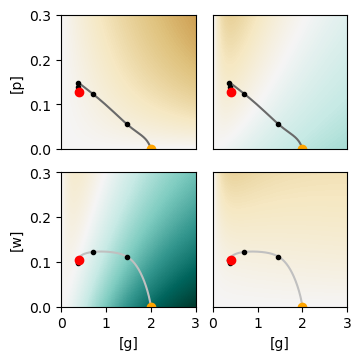

In [7]:
#Display interaction matrix
fig, axAr = plt.subplots(nrows = 2, ncols = 2, constrained_layout = True, figsize=(3.5,3.5))
ax1=axAr[0,0]
ax2=axAr[0,1]
ax3=axAr[1,0]
ax4=axAr[1,1]

cLim = 0.005

ax1.imshow(PonP,cmap='BrBG',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxP], origin='lower')
ax1.set_aspect(maxG/maxP)
ax1.set_xticks([], [])
ax1.set_ylabel('[p]')
ax1.set_xlim([0,maxG])
ax1.set_ylim([0,maxP])
ax1.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[0,:],color='dimgray')
ax1.plot(chemSim.resTimeseries[2,0:-1:1000],chemSim.resTimeseries[0,0:-1:1000],'k.')
ax1.plot(chemSim.rStar[2],chemSim.rStar[0],'ro')
ax1.plot(rIn[2],rIn[0],'o',color='orange')

ax2.imshow(PonW,cmap='BrBG',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxW], origin='lower')
ax2.set_aspect(maxG/maxW)
ax2.set_xticks([], [])
ax2.set_yticks([], [])
ax2.set_xlim([0,maxG])
ax2.set_ylim([0,maxW])
ax2.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[0,:],color='dimgray')
ax2.plot(chemSim.resTimeseries[2,0:-1:1000],chemSim.resTimeseries[0,0:-1:1000],'k.')
ax2.plot(chemSim.rStar[2],chemSim.rStar[0],'ro')
ax2.plot(rIn[2],rIn[0],'o',color='orange')

ax3.imshow(WonP,cmap='BrBG',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxP], origin='lower')
ax3.set_aspect(maxG/maxP)
ax3.set_xlabel('[g]')
ax3.set_ylabel('[w]')
ax3.set_xlim([0,maxG])
ax3.set_ylim([0,maxP])
ax3.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[1,:],color='silver')
ax3.plot(chemSim.resTimeseries[2,0:-1:1000],chemSim.resTimeseries[1,0:-1:1000],'k.')
ax3.plot(chemSim.rStar[2],chemSim.rStar[1],'ro')
ax3.plot(rIn[2],rIn[1],'o',color='orange')

img = ax4.imshow(WonW,cmap='BrBG',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxW], origin='lower')
ax4.set_aspect(maxG/maxW)
ax4.set_yticks([], [])
ax4.set_xlabel('[g]')
ax4.set_xlim([0,maxG])
ax4.set_ylim([0,maxW])
ax4.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[1,:],color='silver')
ax4.plot(chemSim.resTimeseries[2,0:-1:1000],chemSim.resTimeseries[1,0:-1:1000],'k.')
ax4.plot(chemSim.rStar[2],chemSim.rStar[1],'ro')
ax4.plot(rIn[2],rIn[1],'o',color='orange')

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophInteractsTransient.pdf")

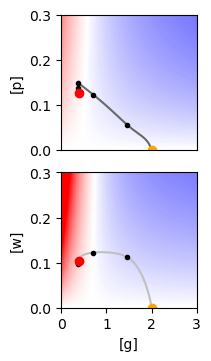

In [8]:
fig, axAr = plt.subplots(nrows = 2, ncols = 1, constrained_layout = True, figsize=(2,3.5))
ax1 = axAr[0]
ax2 = axAr[1]

cLim = 0.001

ax1.imshow(AAp,cmap='bwr',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxP], origin='lower')
ax1.set_aspect(maxG/maxP)
ax1.set_xticks([], [])
ax1.set_ylabel('[p]')
ax1.set_xlim([0,maxG])
ax1.set_ylim([0,maxP])
ax1.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[0,:],color='dimgray')
ax1.plot(chemSim.resTimeseries[2,0:-1:1000],chemSim.resTimeseries[0,0:-1:1000],'k.')
ax1.plot(chemSim.rStar[2],chemSim.rStar[0],'ro')
ax1.plot(rIn[2],rIn[0],'o',color='orange')

ax2.imshow(AAw,cmap='bwr',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxW], origin='lower')
ax2.set_aspect(maxG/maxW)
ax2.set_xlabel('[g]')
ax2.set_ylabel('[w]')
ax2.set_xlim([0,maxG])
ax2.set_ylim([0,maxW])
ax2.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[1,:],color='silver')
ax2.plot(chemSim.resTimeseries[2,0:-1:1000],chemSim.resTimeseries[1,0:-1:1000],'k.')
ax2.plot(chemSim.rStar[2],chemSim.rStar[1],'ro')
ax2.plot(rIn[2],rIn[1],'o',color='orange')

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophAutoAccelTransient.pdf")

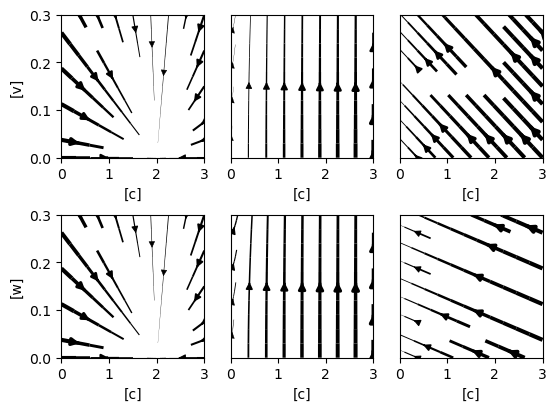

In [9]:
#Display quiver plots of impacts, sensitivities and sigmas
fig, axAr = plt.subplots(nrows = 2, ncols = 3, constrained_layout = True, figsize=(5.5,4))
ax11=axAr[0,0]
ax12=axAr[0,1]
ax13=axAr[0,2]
ax21=axAr[1,0]
ax22=axAr[1,1]
ax23=axAr[1,2]

speed = np.sqrt(np.square(sigW[:,:,2])+np.square(sigW[:,:,1]))
lw = 3*speed / speed.max()
ax11.streamplot(gField,wField,sigW[:,:,2],sigW[:,:,1], density=0.3, color='k', linewidth=lw)
ax11.set_xlim((minG,maxG))
ax11.set_ylim((minW,maxW))
ax11.set_aspect(maxG/maxW)
ax11.set_xlabel('[c]')
ax11.set_ylabel('[v]')

speed = np.sqrt(np.square(sigP[:,:,2])+np.square(sigP[:,:,0]))
lw = 3*speed / speed.max()
ax21.streamplot(gField,pField,sigP[:,:,2],sigP[:,:,0], density=0.3, color='k', linewidth=lw)
ax21.set_xlim((minG,maxG))
ax21.set_ylim((minP,maxP))
ax21.set_aspect(maxG/maxW)
ax21.set_xlabel('[c]')
ax21.set_ylabel('[w]')

speed = np.sqrt(np.square(sensGradsP[:,:,2])+np.square(sensGradsP[:,:,0]))
lw = 3*speed / speed.max()
ax12.streamplot(gField,pField,sensGradsP[:,:,2],sensGradsP[:,:,0], density=0.3, color='k', linewidth = lw)
ax12.set_xlim((minG,maxG))
ax12.set_ylim((minP,maxP))
ax12.set_aspect(maxG/maxW)
ax12.set_xlabel('[c]')
ax12.set_yticks([], [])
ax12.set_yticks([],[])

speed = np.sqrt(np.square(sensGradsW[:,:,2])+np.square(sensGradsW[:,:,1]))
lw = 3*speed / speed.max()
ax22.streamplot(gField,wField,sensGradsW[:,:,2],sensGradsW[:,:,1], density=0.3, color='k', linewidth = lw)
ax22.set_xlim((minG,maxG))
ax22.set_ylim((minW,maxW))
ax22.set_aspect(maxG/maxW)
ax22.set_xlabel('[c]')
ax22.set_yticks([],[])

speed = np.sqrt(np.square(impactsWonP[:,:,2])+np.square(impactsWonP[:,:,0]))
lw = 3*speed / speed.max()
ax13.streamplot(gField,pField,impactsWonP[:,:,2],impactsWonP[:,:,0], density=0.3, color='k', linewidth = lw) #Multiply impact on amino acids by 3 for illustrative purposes
ax13.set_xlim((minG,maxG))
ax13.set_ylim((minP,maxP))
ax13.set_aspect(maxG/maxW)
ax13.set_xlabel('[c]')
ax13.set_yticks([], [])
ax13.set_yticks([], [])

speed = np.sqrt(np.square(impactsPonW[:,:,2])+np.square(impactsPonW[:,:,1]))
lw = 3*speed / speed.max()
ax23.streamplot(gField,wField,impactsPonW[:,:,2],impactsPonW[:,:,1], density=0.3, color='k', linewidth = lw)
ax23.set_xlim((minG,maxG))
ax23.set_ylim((minW,maxW))
ax23.set_aspect(maxG/maxW)
ax23.set_xlabel('[c]')
ax23.set_yticks([], [])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophVectorFields.pdf")

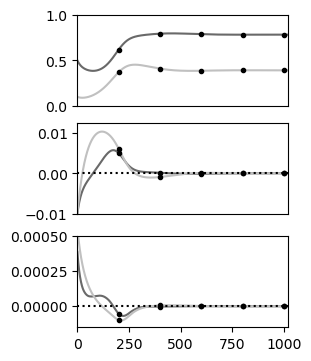

In [10]:
#Display quiver plots of impacts, sensitivities and sigmas
fig, axAr = plt.subplots(nrows = 3, ncols = 1, constrained_layout = True, figsize=(3,3.5))

tSpace = 2000;

GRs = np.zeros((chemSim.resTimeseries.shape[1],2))
for i in range(chemSim.resTimeseries.shape[1]):
    GRs[i,0] = sensFunc(chemSim.resTimeseries[:,i],0,EOparams)
    GRs[i,1] = sensFunc(chemSim.resTimeseries[:,i],1,EOparams)

tRange = np.arange(0,chemSim.tSpan[1],chemSim.dt)

axAr[0].plot(tRange,chemSim.specTimeseries[0,:],color='dimgray')
axAr[0].plot(tRange,chemSim.specTimeseries[1,:],color='silver')
axAr[0].plot(np.arange(tSpace*chemSim.dt,chemSim.tSpan[1],tSpace*chemSim.dt),chemSim.specTimeseries[:,tSpace:100000:tSpace].T,'k.')
axAr[0].set_ylim([0,1])
axAr[0].set_xlim([0,1020])
axAr[0].set_xticks([], [])

axAr[1].plot(tRange,GRs[:,0]-DilRate,color='dimgray')
axAr[1].plot(tRange,GRs[:,1]-DilRate,color='silver')
axAr[1].plot(np.arange(tSpace*chemSim.dt,chemSim.tSpan[1],tSpace*chemSim.dt),GRs[tSpace:100000:tSpace,:]-DilRate,'k.')
axAr[1].plot([0,chemSim.tSpan[1]],[0,0],'k:')
axAr[1].set_ylim([-0.01,0.0125])
axAr[1].set_xlim([0,1020])
axAr[1].set_xticks([], [])

PCGAs = np.diff(GRs,axis=0)/chemSim.dt
axAr[2].plot(tRange[1:],PCGAs[:,0],color='dimgray')
axAr[2].plot(tRange[1:],PCGAs[:,1],color='silver')
axAr[2].plot(np.arange(tSpace*chemSim.dt,chemSim.tSpan[1],tSpace*chemSim.dt),PCGAs[tSpace:100000:tSpace,:],'k.')
axAr[2].plot([0,chemSim.tSpan[1]],[0,0],'k:')
axAr[2].set_xlim([0,1020])
axAr[2].set_ylim([-0.00015,0.0005])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophRatesAndAccels.pdf")

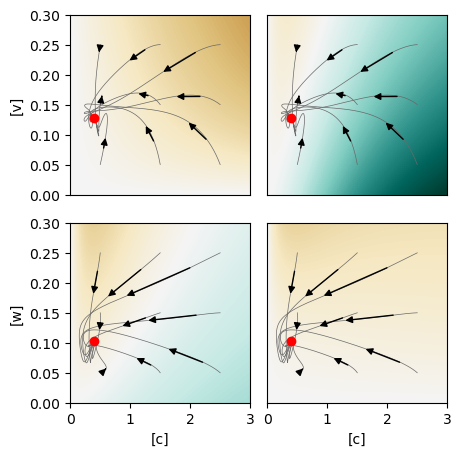

In [11]:
#Display interaction matrix
fig, axAr = plt.subplots(nrows = 2, ncols = 2, constrained_layout = True, figsize=(4.5,4.5))
ax1=axAr[0,0]
ax2=axAr[0,1]
ax3=axAr[1,0]
ax4=axAr[1,1]

cLim = 0.005

ax1.imshow(PonP,cmap='BrBG',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxP], origin='lower')
ax1.set_aspect(maxG/maxP)
ax1.set_xticks([], [])
ax1.set_ylabel('[v]')
ax1.set_xlim([0,maxG])
ax1.set_ylim([0,maxP])

ax2.imshow(WonP,cmap='BrBG',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxW], origin='lower')
ax2.set_aspect(maxG/maxW)
ax2.set_xticks([], [])
ax2.set_yticks([], [])
ax2.set_xlim([0,maxG])
ax2.set_ylim([0,maxW])

ax3.imshow(PonW,cmap='BrBG',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxP], origin='lower')
ax3.set_aspect(maxG/maxP)
ax3.set_xlabel('[c]')
ax3.set_ylabel('[w]')
ax3.set_xlim([0,maxG])
ax3.set_ylim([0,maxP])

img = ax4.imshow(WonW,cmap='BrBG',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxW], origin='lower')
ax4.set_aspect(maxG/maxW)
ax4.set_yticks([], [])
ax4.set_xlabel('[c]')
ax4.set_xlim([0,maxG])
ax4.set_ylim([0,maxW])

#Generate a chemostat model to get equilibrium r*
B0 = np.array([0.5,0.5])

t1 = 80
t2 = 200

for pConc in np.arange(minP+0.05,maxP,0.1):
    for gConc in np.arange(minG+0.5,maxG,1):
        r0 = np.array([pConc,0,gConc])
        chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,r0)
        chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
        chemSim.set_dilSettings(D=DilRate,transT=0.1)
        chemSim.set_instInteract(instInteract)
        chemSim.set_intrinsicGR(intrinsicGR)
        chemSim.simEOmodel('Chemostat')

        ax1.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[0,:],lw=0.5,color='dimgrey')
        ax2.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[0,:],lw=0.5,color='dimgrey')
       
        ax1.annotate("", xytext=(chemSim.resTimeseries[2,t1], chemSim.resTimeseries[0,t1]), 
            xy=(chemSim.resTimeseries[2,t2], chemSim.resTimeseries[0,t2]),
            arrowprops=dict(arrowstyle="-|>",facecolor='black'))
        ax2.annotate("", xytext=(chemSim.resTimeseries[2,t1], chemSim.resTimeseries[0,t1]), 
            xy=(chemSim.resTimeseries[2,t2], chemSim.resTimeseries[0,t2]),
            arrowprops=dict(arrowstyle="-|>",facecolor='black'))

t1 = 100
t2 = 300

for wConc in np.arange(minW+0.05,maxW,0.1):
    for gConc in np.arange(minG+0.5,maxG,1):
        r0 = np.array([0,wConc,gConc])
        chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,r0)
        chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
        chemSim.set_dilSettings(D=DilRate,transT=0.1)
        chemSim.set_instInteract(instInteract)
        chemSim.set_intrinsicGR(intrinsicGR)
        chemSim.simEOmodel('Chemostat')

        ax3.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[1,:],lw=0.5,color='dimgrey')
        ax4.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[1,:],lw=0.5,color='dimgrey')

        ax3.annotate("", xytext=(chemSim.resTimeseries[2,t1], chemSim.resTimeseries[1,t1]), 
            xy=(chemSim.resTimeseries[2,t2], chemSim.resTimeseries[1,t2]),
            arrowprops=dict(arrowstyle="-|>",facecolor='black'))
        ax4.annotate("", xytext=(chemSim.resTimeseries[2,t1], chemSim.resTimeseries[1,t1]), 
            xy=(chemSim.resTimeseries[2,t2], chemSim.resTimeseries[1,t2]),
            arrowprops=dict(arrowstyle="-|>",facecolor='black'))

chemSim.rStar = chemSim.resTimeseries[:,-1]

ax1.plot(chemSim.rStar[2],chemSim.rStar[0],'ro')
ax2.plot(chemSim.rStar[2],chemSim.rStar[0],'ro')
ax3.plot(chemSim.rStar[2],chemSim.rStar[1],'ro')
ax4.plot(chemSim.rStar[2],chemSim.rStar[1],'ro')

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophInteractsEquilibria.pdf")

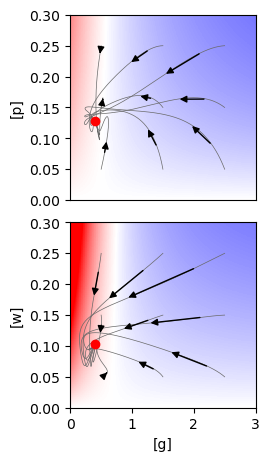

In [37]:
fig, axAr = plt.subplots(nrows = 2, ncols = 1, constrained_layout = True, figsize=(2.8,4.5))
ax1 = axAr[0]
ax2 = axAr[1]

cLim = 0.001

ax1.imshow(AAp,cmap='bwr',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxP], origin='lower')
ax1.set_aspect(maxG/maxP)
ax1.set_xticks([], [])
ax1.set_ylabel('[p]')
ax1.set_xlim([0,maxG])
ax1.set_ylim([0,maxP])

ax2.imshow(AAw,cmap='bwr',aspect='auto',vmin = -cLim, vmax = cLim,extent=[0,maxG,0,maxW], origin='lower')
ax2.set_aspect(maxG/maxW)
ax2.set_xlabel('[g]')
ax2.set_ylabel('[w]')
ax2.set_xlim([0,maxG])
ax2.set_ylim([0,maxW])

#Generate a chemostat model to get equilibrium r*
B0 = np.array([0.5,0.5])

t1 = 80
t2 = 200

for pConc in np.arange(minP+0.05,maxP,0.1):
    for gConc in np.arange(minG+0.5,maxG,1):
        r0 = np.array([pConc,0,gConc])
        chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,r0)
        chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
        chemSim.set_dilSettings(D=DilRate,transT=0.1)
        chemSim.set_instInteract(instInteract)
        chemSim.set_intrinsicGR(intrinsicGR)
        chemSim.simEOmodel('Chemostat')

        ax1.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[0,:],lw=0.5,color='dimgrey')
 
        ax1.annotate("", xytext=(chemSim.resTimeseries[2,t1], chemSim.resTimeseries[0,t1]), 
            xy=(chemSim.resTimeseries[2,t2], chemSim.resTimeseries[0,t2]),
            arrowprops=dict(arrowstyle="-|>",facecolor='black'))

t1 = 100
t2 = 300

for wConc in np.arange(minW+0.05,maxW,0.1):
    for gConc in np.arange(minG+0.5,maxG,1):
        r0 = np.array([0,wConc,gConc])
        chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,r0)
        chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
        chemSim.set_dilSettings(D=DilRate,transT=0.1)
        chemSim.set_instInteract(instInteract)
        chemSim.set_intrinsicGR(intrinsicGR)
        chemSim.simEOmodel('Chemostat')

        ax2.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[1,:],lw=0.5,color='dimgrey')

        ax2.annotate("", xytext=(chemSim.resTimeseries[2,t1], chemSim.resTimeseries[1,t1]), 
            xy=(chemSim.resTimeseries[2,t2], chemSim.resTimeseries[1,t2]),
            arrowprops=dict(arrowstyle="-|>",facecolor='black'))

chemSim.rStar = chemSim.resTimeseries[:,-1]

ax1.plot(chemSim.rStar[2],chemSim.rStar[0],'ro')
ax2.plot(chemSim.rStar[2],chemSim.rStar[1],'ro')

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\AuxotrophAutoAccelEquilibria.pdf")

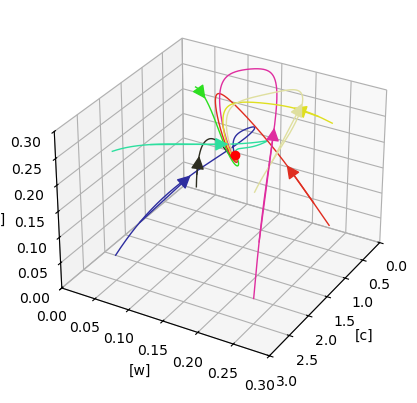

In [33]:
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))

        return np.min(zs)

ax = plt.figure().add_subplot(projection='3d')

for wConc in np.arange(minW+0.05,maxW,0.2):
    for pConc in np.arange(minP+0.05,maxP,0.2):
        for gConc in np.arange(minG+0.5,maxG,2):
            r0 = np.array([pConc,wConc,gConc])
            chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,r0)
            chemSim.set_timeSettings(tSpan = [0,5000], dt=0.1)
            chemSim.set_dilSettings(D=DilRate,transT=0.1)
            chemSim.set_instInteract(instInteract)
            chemSim.set_intrinsicGR(intrinsicGR)
            chemSim.simEOmodel('Chemostat')
    
            ax.plot(chemSim.resTimeseries[2,:],chemSim.resTimeseries[1,:],chemSim.resTimeseries[0,:],lw=1,color=[wConc*3.5,pConc*3.5,gConc/4])

            arrow_prop_dict = dict(mutation_scale=20, arrowstyle='-|>', color=[wConc*3.5,pConc*3.5,gConc/4], shrinkA=0, shrinkB=0)
            a = Arrow3D([chemSim.resTimeseries[2,t1], chemSim.resTimeseries[2,t2]],
                        [chemSim.resTimeseries[1,t1], chemSim.resTimeseries[1,t2]], 
                        [chemSim.resTimeseries[0,t1], chemSim.resTimeseries[0,t2]], **arrow_prop_dict)

            ax.add_artist(a)

ax.plot(chemSim.resTimeseries[2,-1],chemSim.resTimeseries[1,-1],chemSim.resTimeseries[0,-1],'ro')

ax.set_xlim([minG,maxG])
ax.set_ylim([minW,maxW])
ax.set_zlim([minP,maxP])

ax.set_xlabel('[c]')
ax.set_ylabel('[w]')
ax.set_zlabel('[v]')

ax.view_init(30, 30, 0)

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\Auxotroph3Dequilibrium.pdf")